<a href="https://colab.research.google.com/github/jajajandro/LIP_updated-codes/blob/main/Template_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import modules

In [410]:
from __future__ import division
from __future__ import print_function

#matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas
import timeit #more accurate than time

#import theano
import tensorflow

from sklearn.decomposition import PCA
import joblib
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import keras
from keras import backend as K
from keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from keras.layers import Dense, Activation, Dropout
from keras.models import Sequential, model_from_json, load_model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.optimizers import Adam

from sklearn.utils import shuffle

import seaborn as sns
sns.set_style("white")
import os
import json
#import shap


from six.moves import cPickle #Faster than pickle

from google.colab import drive
drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/LIP_internships26_SNDNue/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Configure data

## Load Signal Samples

### Load the signal
---

In [411]:
signal_df = pandas.read_csv(project_path+"signal.csv")
background_df = pandas.read_csv(project_path+"background.csv")

In [412]:
FullSignal = pandas.concat([signal_df, background_df], ignore_index=True)

In [413]:
def plotCorrelation(df):
  corr_matrix = df.corr()

  fig, ax = plt.subplots(figsize=(6, 8))

  im = ax.imshow(corr_matrix, interpolation='nearest')

  # labels
  ax.set_xticks(np.arange(len(corr_matrix.columns)))
  ax.set_yticks(np.arange(len(corr_matrix.columns)))

  ax.set_xticklabels(corr_matrix.columns, rotation=90)
  ax.set_yticklabels(corr_matrix.columns)

  # colorbar
  plt.colorbar(im, shrink = 0.7)

  plt.title("Correlation Matrix")

  plt.tight_layout()

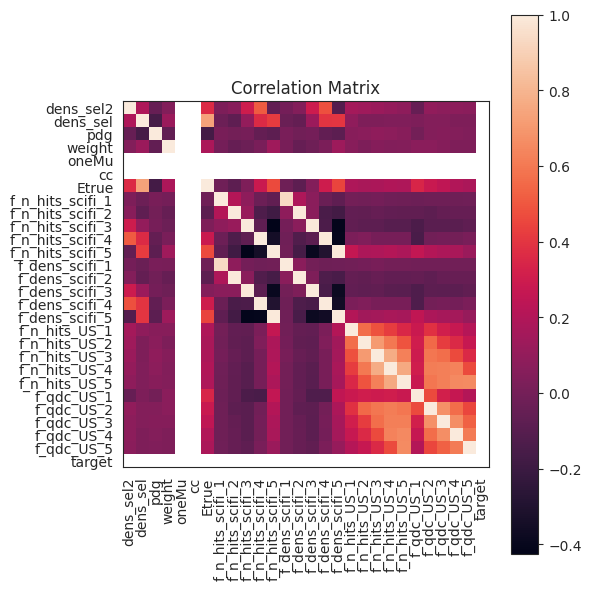

In [414]:
plotCorrelation(signal_df)

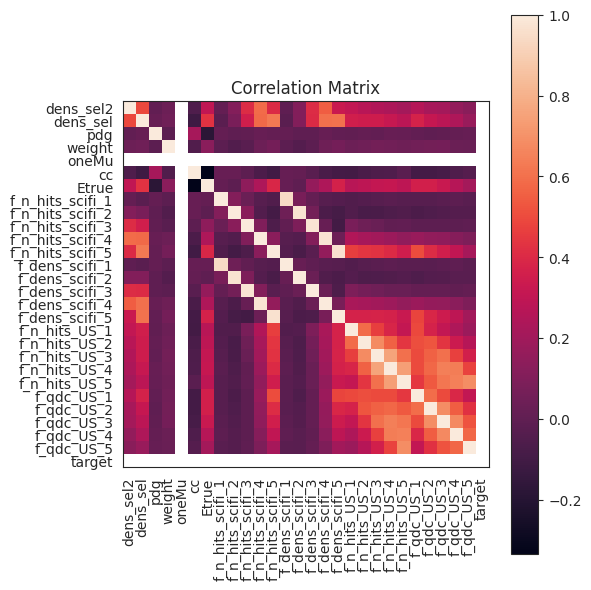

In [415]:
plotCorrelation(background_df)

### Load the background

### Fixing and merging our datasets
Since these two template samples are not written in the same format we will do a bit of fixing to merge them correctly before proceeding with the ML

In [416]:
FullSignal.drop(columns = [ "weight", "cc", "oneMu", "pdg"], inplace = True)
FullSignal

,dens_sel2,dens_sel,Etrue,f_n_hits_scifi_1,f_n_hits_scifi_2,f_n_hits_scifi_3,f_n_hits_scifi_4,f_n_hits_scifi_5,f_dens_scifi_1,f_dens_scifi_2,...,f_n_hits_US_2,f_n_hits_US_3,f_n_hits_US_4,f_n_hits_US_5,f_qdc_US_1,f_qdc_US_2,f_qdc_US_3,f_qdc_US_4,f_qdc_US_5,target
0,2,24370,716.562591,0,0,3,8,906,0.0,0.0,...,6,9,7,6,42265.724968,7866.549934,11421.531047,6197.103906,777.925980,1.0
1,8062,21864,590.444082,0,2,786,434,102,0.0,2.0,...,8,4,1,1,4866.257365,4309.979417,409.397816,59.595423,72.966911,1.0
2,15518,16780,770.281065,0,4,5,673,660,0.0,4.0,...,9,9,6,6,9734.940929,7121.094282,1777.185069,659.866430,217.803210,1.0
3,694,23502,630.117433,0,0,29,904,127,0.0,0.0,...,7,9,8,6,1473.472986,4493.734835,5943.236901,3134.711505,154.480858,1.0
4,6956,12508,339.604380,0,0,4,483,350,0.0,0.0,...,8,4,6,0,2329.217301,451.262323,1906.230902,532.829734,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10877,18,5766,95.086014,0,4,314,31,4,0.0,4.0,...,3,1,2,0,64.303642,721.652317,53.254194,330.696665,0.000000,0.0
10878,24,1208,73.247683,0,0,0,109,17,0.0,0.0,...,8,6,3,2,1156.316231,841.447451,689.317762,236.960054,69.607474,0.0
10879,1344,1186,172.365122,0,0,0,126,189,0.0,0.0,...,9,10,4,3,7502.329371,4848.185713,1443.609117,981.862633,261.696697,0.0
10880,82,3840,201.731998,0,2,8,257,41,0.0,2.0,...,7,5,3,0,1869.327618,1757.722168,224.990139,53.669718,0.000000,0.0


## Create development and validation samples

### Normalize the samples

Before creating the validation and development samples we need to normalize our dataset, since the normalization methods are done in respect to the sample fed to the pipeline. This means that if we select subsamples first and normalize them afterwards, the normalization will be slightly different every time.

Here we define a SK-Learn pipeline which will contain transformation steps for any data fed in. Pipelines are a nice, compact way of handing data transformations.

In [417]:
normIn = True #True #Whether we want to normalise and standardise the inputs
pca = False #True #Whether we want to use principal-component analysis to decorrelate inputs
whiten = False #True #Whether we want to whiten input data

stepsIn = []
if not normIn and not pca:
    stepsIn.append(('ident', StandardScaler(with_mean=False, with_std=False))) #For compatability
else:
    if normIn:
        stepsIn.append(('normIn', StandardScaler()))
    if pca:
        stepsIn.append(('pca', PCA(whiten=whiten)))
inputPipe = Pipeline(stepsIn)
stepsOut = []

In order to normalize our data we need to define which variables we want to use in our analysis. We define those in the block below

In [418]:
# Lista de variables a excluir del entrenamiento
# Puedes añadir aquí cualquier variable que consideres que no aporta información
exclude_vars = ['target', 'signal_probability']

# Creamos trainFeatures excluyendo las variables de la lista
trainFeatures = [var for var in FullSignal.columns if var not in exclude_vars]

print(f"Variables seleccionadas para el entrenamiento ({len(trainFeatures)}):")
print(trainFeatures)

Variables seleccionadas para el entrenamiento (23):
['dens_sel2', 'dens_sel', 'Etrue', 'f_n_hits_scifi_1', 'f_n_hits_scifi_2', 'f_n_hits_scifi_3', 'f_n_hits_scifi_4', 'f_n_hits_scifi_5', 'f_dens_scifi_1', 'f_dens_scifi_2', 'f_dens_scifi_3', 'f_dens_scifi_4', 'f_dens_scifi_5', 'f_n_hits_US_1', 'f_n_hits_US_2', 'f_n_hits_US_3', 'f_n_hits_US_4', 'f_n_hits_US_5', 'f_qdc_US_1', 'f_qdc_US_2', 'f_qdc_US_3', 'f_qdc_US_4', 'f_qdc_US_5']


We put the normalized data into NormFullSignal, and only afterwards do we create our test and validation samples


In [419]:
#Recall that the output from NormFullSignal is an array (numpy like)
NormFullSignal = inputPipe.fit_transform(FullSignal[trainFeatures].values.astype('float32'))

#Notice that since we normalized our data and applied a PCA the variables are no longer physical, and also would not have units
#However, in order to create a dataframe we need a placeholder name for each column, and this is practical
NormFullSignalDF = pandas.DataFrame(NormFullSignal, columns=trainFeatures)

#We are using iloc in order to select from event iloc[first_event:last_event,first_column:last_column],
NormSignal = NormFullSignalDF.iloc[0:len(signal_df),:]
NormBackground = NormFullSignalDF.iloc[len(signal_df):len(FullSignal),:]

In [420]:
NormFullSignalDF.tail()

,dens_sel2,dens_sel,Etrue,f_n_hits_scifi_1,f_n_hits_scifi_2,f_n_hits_scifi_3,f_n_hits_scifi_4,f_n_hits_scifi_5,f_dens_scifi_1,f_dens_scifi_2,...,f_n_hits_US_1,f_n_hits_US_2,f_n_hits_US_3,f_n_hits_US_4,f_n_hits_US_5,f_qdc_US_1,f_qdc_US_2,f_qdc_US_3,f_qdc_US_4,f_qdc_US_5
10877,-0.578057,-0.540823,-0.887570,-0.109682,-0.178209,0.828195,-0.753639,-0.949261,-0.046209,-0.169948,...,-2.867075,-1.519842,-1.390322,-0.514679,-0.828659,-0.584462,-0.492495,-0.582417,-0.215844,-0.413024
10878,-0.576434,-1.001323,-0.943546,-0.109682,-0.226260,-0.503684,-0.492809,-0.901742,-0.046209,-0.170862,...,0.293169,0.592786,0.294288,-0.179586,-0.037584,-0.439523,-0.456614,-0.271499,-0.300635,-0.291903
10879,-0.219340,-1.003546,-0.689488,-0.109682,-0.226260,-0.503684,-0.435961,-0.273033,-0.046209,-0.170862,...,0.819876,1.015312,1.641976,0.155506,0.357954,0.402759,0.743458,0.097210,0.373179,0.042342
10880,-0.560744,-0.735409,-0.614215,-0.109682,-0.202235,-0.469751,0.002101,-0.814015,-0.046209,-0.170405,...,-0.233538,0.170261,-0.042634,-0.179586,-0.828659,-0.344888,-0.182178,-0.498470,-0.466434,-0.413024
10881,-0.582386,-1.073662,-0.424878,-0.109682,-0.226260,-0.503684,-0.843927,-0.678770,-0.046209,-0.170862,...,-0.233538,-1.519842,-1.727244,-1.184864,-0.828659,-0.456270,-0.680525,-0.608449,-0.514981,-0.413024


### Creating the samples to test and validate our NN
We look at what data-set has the least events, and select an analogous amount of the other set randomly to avoid bias towards one kkk

Here we divide our samples into a 60/20/20 split in order to train with a part of our subset, and validate our model with the other part.

In [421]:
NormSignal['target'] = 1.0
NormBackground['target'] = 0.0

sigratio = 1
backratio = 1
if len(signal_df) < len(background_df):
  backratio = len(signal_df)/len(background_df)
  print(backratio)
else:
  sigratio = len(background_df)/len(signal_df)
  print(sigratio)


# Creates a column that defines the target score that we want to achieve in each data set
# This is a good way of dividing the datasets when they are relatively similar in sizes
Sig_train, Sig_test = \
                train_test_split([i for i in NormSignal.index.tolist()],
                                 test_size=(1-0.8*sigratio), random_state=1337)
Back_train, Back_test = \
                train_test_split([i for i in NormBackground.index.tolist()],
                                 test_size=(1-0.8*backratio), random_state=1337)

trainSig = NormSignal.loc[Sig_train].copy()
trainBack = NormBackground.loc[Back_train].copy()
testData = pandas.concat([NormSignal.loc[Sig_test],NormBackground.loc[Back_test]], ignore_index=True)


# First we randomly divide the data into 80/20, and set 20% aside to test our NN
# and then with the reamining 80% we divide it into 60/20, with 60% to train the
# NN and 20% for the validation sample

Sig_dev, Sig_val = \
                train_test_split([i for i in trainSig.index.tolist()],
                                 test_size=(1-0.75), random_state=1337)
Back_dev, Back_val = \
                train_test_split([i for i in trainBack.index.tolist()],
                                 test_size=(1-0.75), random_state=1337)

devData = pandas.concat([trainSig.loc[Sig_dev],trainBack.loc[Back_dev]], ignore_index=True)
valData = pandas.concat([trainSig.loc[Sig_val],trainBack.loc[Back_val]], ignore_index=True)

print(len(Sig_train))
print(len(Back_train))
print(len(Sig_dev))
print(len(Back_dev))
print(len(Sig_val))
print(len(Back_val))
print(len(Sig_test))
print(len(Back_test))

0.5998235812996178
3264
3264
2448
2448
816
816
816
3538


/tmp/ipykernel_31241/288217268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NormSignal['target'] = 1.0
/tmp/ipykernel_31241/288217268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NormBackground['target'] = 0.0


After all of this, we create the training and validation arrays that will be fed onto the network

In [422]:
Features1 = [var for var in devData.columns if str.startswith(var, "target")]

X_class_train = devData[trainFeatures].values.astype('float32')
y_class_train = devData[Features1].values.astype('float32')

X_class_val = valData[trainFeatures].values.astype('float32')
y_class_val = valData[Features1].values.astype('float32')

X_class_test = testData[trainFeatures].values.astype('float32')
y_class_test = testData[Features1].values.astype('float32')

print(trainFeatures)
print(Features1)
#devData

['dens_sel2', 'dens_sel', 'Etrue', 'f_n_hits_scifi_1', 'f_n_hits_scifi_2', 'f_n_hits_scifi_3', 'f_n_hits_scifi_4', 'f_n_hits_scifi_5', 'f_dens_scifi_1', 'f_dens_scifi_2', 'f_dens_scifi_3', 'f_dens_scifi_4', 'f_dens_scifi_5', 'f_n_hits_US_1', 'f_n_hits_US_2', 'f_n_hits_US_3', 'f_n_hits_US_4', 'f_n_hits_US_5', 'f_qdc_US_1', 'f_qdc_US_2', 'f_qdc_US_3', 'f_qdc_US_4', 'f_qdc_US_5']
['target']


## Training options

Training options for a binary separation

In [423]:
classTrainFeatures = trainFeatures #The features used
classModel = "model0" #Will define the layout of the network
varSet = "trainFeatures" #Name of the feature set used, mainly for saving results
nSplits = 1 #Number of train/test splits to make during cross-validation
ensembleSize = 1 #Number of classifiers  to include in ensemble = min(nSplits, ensembleSize)
ensembleMode = 'loss'#accuracy'#'loss' #Metric used to weight classifiers in ensemble
nad=Nadam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
sgd=SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
#categorical_cross_entropy para várias amostras de sinal
compileArgs = {'loss':'binary_crossentropy',
               'optimizer':'Adam'}#,'metrics':['acc']} #Loss function and optimiser for NN
trainParams = {'epochs' : 1000,
               'batch_size' : 500,
               'verbose' : 2} #Maximum epochs for training and size of mini-batch
print("Training on {} features {}". format(len(classTrainFeatures),[var for var in classTrainFeatures]))

Training on 23 features ['dens_sel2', 'dens_sel', 'Etrue', 'f_n_hits_scifi_1', 'f_n_hits_scifi_2', 'f_n_hits_scifi_3', 'f_n_hits_scifi_4', 'f_n_hits_scifi_5', 'f_dens_scifi_1', 'f_dens_scifi_2', 'f_dens_scifi_3', 'f_dens_scifi_4', 'f_dens_scifi_5', 'f_n_hits_US_1', 'f_n_hits_US_2', 'f_n_hits_US_3', 'f_n_hits_US_4', 'f_n_hits_US_5', 'f_qdc_US_1', 'f_qdc_US_2', 'f_qdc_US_3', 'f_qdc_US_4', 'f_qdc_US_5']


## Define classifier

Classifier for the binary separation

In [424]:
def getClassifier(model, nIn, compileArgs):
    classModel = Sequential()
    depth = None
    width = None
    if model == "model0":
        depth = 3
        width = 20

    # Usamos nIn para definir la forma de entrada dinámicamente
    classModel.add(Dense(width, input_shape=(nIn,), kernel_initializer='normal', activation='relu'))
    classModel.add(Activation('relu'))

    for i in range(depth):
        classModel.add(Dense(width, kernel_initializer='normal', activation='relu'))

    classModel.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))
    classModel.compile(**compileArgs)
    return classModel

### Callbacks

Callbacks are methods that can be called during training. They have a variety of uses such as monitoring training, stopping training early, and saving different versions of the model. Here we define our own callback,  which saves the history of the training.

We want to view the history of the model's performance on the training and testing data during data, however by default the training loss is averaged over the epoch, and the test loss is evaluated at the end of the epoch, so is not comparable. This modified version evaluates the performance on the training data at the end of each epoch.

Later well also use some other callbacks:

EarlyStopping monitors a specified metric and stops the training if the performance fails to improve for a specified number of epochs in a row. Here we use it to monitor the loss on the test data and stop when it doesn't improve after 10 epochs.

ModelCheckpoint is used to save the weights of the network during training. It's quite flexible, but here we use it save the model which performs best according to the loss in test data.

Normally during training, the test loss will reach a minimum and either saturate or start to increase (overtraining). The training loss will normally either saturate or continue to decrease. The optimum point is when the test-loss first reaches its minimum point. The combination of EarlyStopping and ModelCheckpoint acts to save the model at this point and allow some leeway in case it starts to decrease again.

In [425]:
class LossHistory(Callback):
    def __init__(self, trData):
        self.trainingData = trData
    def on_train_begin(self, logs={}):
        self.losses = {}
        self.losses['loss'] = []
        self.losses['val_loss'] = []

    def on_epoch_end(self, epoch, logs={}):
        self.losses['loss'].append(self.model.evaluate(self.trainingData[0], self.trainingData[1], verbose=0))
        self.losses['val_loss'].append(logs.get('val_loss'))

In [426]:
class EarlyStoppingByLossVal(Callback):
    def __init__(self, monitor='val_loss', value=0.00001, verbose=0):
        super(Callback, self).__init__()
        self.monitor = monitor
        self.value = value
        self.verbose = verbose

    def on_epoch_end(self, epoch, logs={}):
        current = logs.get(self.monitor)
        if current is None:
            warnings.warn("Early stopping requires %s available!" % self.monitor, RuntimeWarning)

        if current < self.value:
            if self.verbose > 0:
                print("Epoch %05d: early stopping THR" % epoch)
            self.model.stop_training = True

## Train classifier

In [427]:
start = timeit.default_timer()

results = []
histories = []

os.chdir(project_path) #Here you should put the directory where you will save the weight files for the NNs

os.system("mkdir train_weights")
os.system("rm train_weights/*.h5")
os.system("rm train_weights/*.json")
os.system("rm train_weights/*.pkl")

model = None # Clearing the NN
model = getClassifier(classModel, len(classTrainFeatures), compileArgs)
#model.reset_states #Just checking

lossHistory = LossHistory((X_class_train, y_class_train))
earlyStop = EarlyStopping(monitor='val_loss', patience=50, verbose=1, mode='auto')
saveBest = ModelCheckpoint("train_weights/best.weights.h5", monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=True, mode='auto')

#Begin training the model
C = model.fit(X_class_train, y_class_train, validation_data = (X_class_val, y_class_val), callbacks = [earlyStop, saveBest, lossHistory], **trainParams)

histories.append(lossHistory.losses) #Saves the loss history from callback
model.load_weights("train_weights/best.weights.h5") #Loads the best model saved by ModelCheckpoint

results.append({})

results[-1]['loss'] = model.evaluate(X_class_val, y_class_val, verbose=0) #Gets loss on test data
#results[-1]['AUC'] = 1-roc_auc_score(y_class_val, model.predict(X_class_val, verbose=0)) #Gets ROC AUC for test data

#print("Score is:", results[-1])

model.save('train_weights/train.h5') #Save the model

with open('train_weights/resultsFile.pkl', 'wb') as fout: #Save results
    cPickle.dump(results, fout)

print("Cross-validation took {:.3f}s ".format(timeit.default_timer() - start))

model.summary() #Prints a summary of the model layout
model = None



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1000
10/10 - 4s - 390ms/step - loss: 0.6931 - val_loss: 0.6930
Epoch 2/1000
10/10 - 1s - 82ms/step - loss: 0.6927 - val_loss: 0.6922
Epoch 3/1000
10/10 - 1s - 86ms/step - loss: 0.6911 - val_loss: 0.6893
Epoch 4/1000
10/10 - 1s - 79ms/step - loss: 0.6859 - val_loss: 0.6811
Epoch 5/1000
10/10 - 1s - 132ms/step - loss: 0.6719 - val_loss: 0.6600
Epoch 6/1000
10/10 - 1s - 57ms/step - loss: 0.6393 - val_loss: 0.6146
Epoch 7/1000
10/10 - 1s - 53ms/step - loss: 0.5782 - val_loss: 0.5449
Epoch 8/1000
10/10 - 1s - 54ms/step - loss: 0.5023 - val_loss: 0.4827
Epoch 9/1000
10/10 - 1s - 58ms/step - loss: 0.4410 - val_loss: 0.4329
Epoch 10/1000
10/10 - 1s - 52ms/step - loss: 0.3929 - val_loss: 0.3989
Epoch 11/1000
10/10 - 1s - 55ms/step - loss: 0.3655 - val_loss: 0.3816
Epoch 12/1000
10/10 - 1s - 52ms/step - loss: 0.3519 - val_loss: 0.3723
Epoch 13/1000
10/10 - 1s - 52ms/step - loss: 0.3440 - val_loss: 0.3650
Epoch 14/1000
10/10 - 1s - 52ms/step - loss: 0.3372 - val_loss: 0.3584
Epoch 15/1000

Cross-validation took 55.477s 


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 20)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,285 (20.65 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,524 (13.77 KB)

In [428]:
# 1. resultados del train (train.h5)
from google.colab import drive
drive.mount('/content/drive')

import h5py

# 2. Definir la ruta exacta del archivo
file_path = '/content/drive/MyDrive/LIP_internships26_SNDNue/train_weights/train.h5'

# 3. Abrir el archivo en modo lectura ('r') y explorar su contenido
with h5py.File(file_path, 'r') as f:
    print("--- Estructura del archivo H5 ---")
    print("Claves (Keys) disponibles:", list(f.keys()))
    print("-" * 33)

    # Este bucle te mostrará automáticamente qué contiene cada clave y su tamaño (shape)
    for key in f.keys():
        # Si es un grupo (como una carpeta interna), listamos su contenido
        if isinstance(f[key], h5py.Group):
            print(f"📁 [Grupo] {key} -> Contiene sub-claves: {list(f[key].keys())}")
        # Si es un dataset (un array de datos directo)
        elif isinstance(f[key], h5py.Dataset):
            print(f"📊 [Dataset] {key} -> Forma/Shape: {f[key].shape}, Tipo: {f[key].dtype}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Estructura del archivo H5 ---
Claves (Keys) disponibles: ['model_weights', 'optimizer_weights']
---------------------------------
📁 [Grupo] model_weights -> Contiene sub-claves: ['activation_12', 'dense_60', 'dense_61', 'dense_62', 'dense_63', 'dense_64', 'top_level_model_weights']
📁 [Grupo] optimizer_weights -> Contiene sub-claves: ['adam']


In [429]:
# 2. resultados de los pesos del train (best weights)
from google.colab import drive
drive.mount('/content/drive')

import h5py

# 2. Definir la ruta exacta del archivo
file_path = '/content/drive/MyDrive/LIP_internships26_SNDNue/train_weights/best.weights.h5'

# 3. Abrir el archivo en modo lectura ('r') y explorar su contenido
with h5py.File(file_path, 'r') as f:
    print("--- Estructura del archivo H5 ---")
    print("Claves (Keys) disponibles:", list(f.keys()))
    print("-" * 33)

    # Este bucle te mostrará automáticamente qué contiene cada clave y su tamaño (shape)
    for key in f.keys():
        # Si es un grupo (como una carpeta interna), listamos su contenido
        if isinstance(f[key], h5py.Group):
            print(f"📁 [Grupo] {key} -> Contiene sub-claves: {list(f[key].keys())}")
        # Si es un dataset (un array de datos directo)
        elif isinstance(f[key], h5py.Dataset):
            print(f"📊 [Dataset] {key} -> Forma/Shape: {f[key].shape}, Tipo: {f[key].dtype}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Estructura del archivo H5 ---
Claves (Keys) disponibles: ['layers', 'optimizer', 'vars']
---------------------------------
📁 [Grupo] layers -> Contiene sub-claves: ['activation', 'dense', 'dense_1', 'dense_2', 'dense_3', 'dense_4']
📁 [Grupo] optimizer -> Contiene sub-claves: ['vars']
📁 [Grupo] vars -> Contiene sub-claves: []


## Construct ensemble
During the *k*-fold CV we trained *k* models. We could just use the best one, however it is unlikely to optimimum for all input possibilities. Ensembling is a method of using multiple classifiers together to achieve a better result than a single one on its own.

The method I use here is to weight the contributions of each classifier according to how well it performed on its test set during CV.

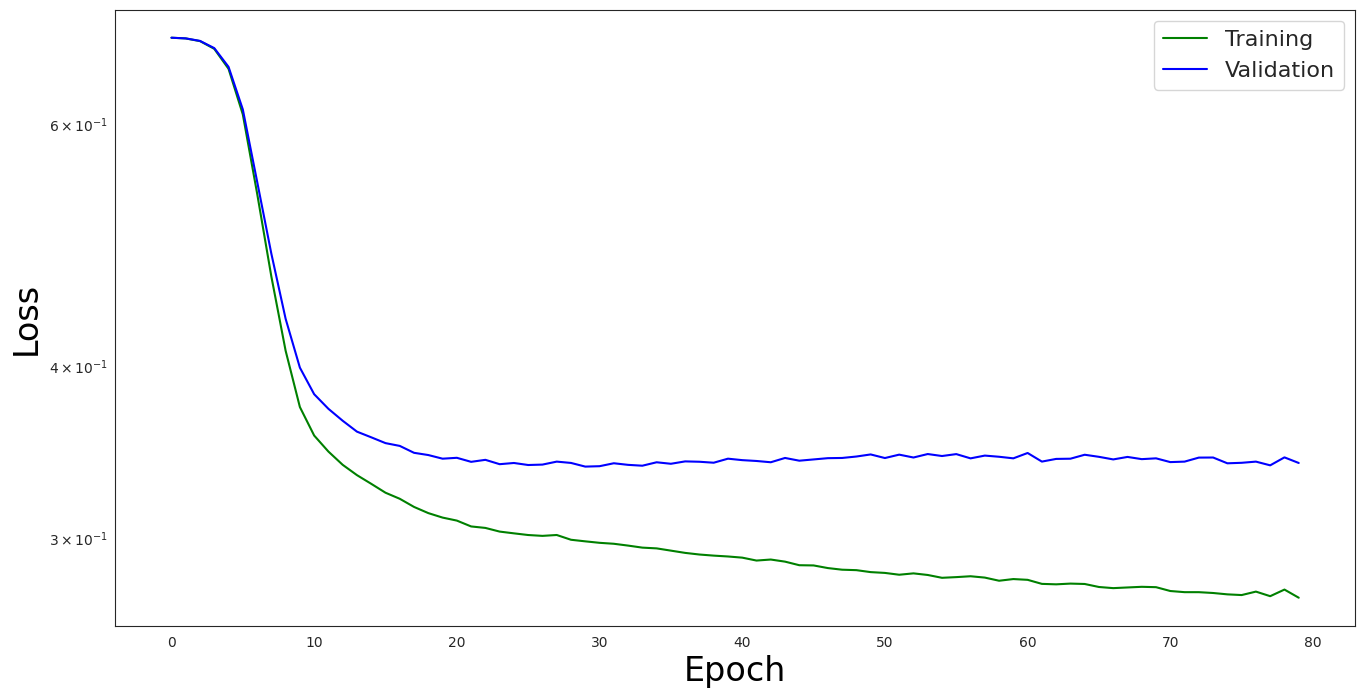

In [430]:
plt.figure(figsize=(16,8))
#print(model.predict(X_class))
for i, history in enumerate(histories):
    if i == 0:
        plt.plot(history['loss'], color='g', label='Training')
        plt.plot(history['val_loss'], color='b', label='Validation')
    else:
        plt.plot(history['loss'], color='g')
        plt.plot(history['val_loss'], color='b')

plt.legend(fontsize=16)
plt.xlabel("Epoch", fontsize=24, color='black')
plt.ylabel("Loss", fontsize=24, color='black')
plt.yscale('log')
plt.show()

# Accessing Previous NNs and Applying them to Data

In [431]:
results = None
with open('train_weights/resultsFile.pkl', 'rb') as fin: #Reload results in case notebook was closed
    results = cPickle.load(fin)

In [432]:
model = load_model('train_weights/train.h5')

## Response on dev and val data

In [433]:
# Applying our data to the NNs in order to get an array with the score (probability) of it being a signal event
pred_train = model.predict(X_class_train, verbose=0)
pred_val = model.predict(X_class_val, verbose=0)
pred_full_Data = model.predict(NormFullSignal, verbose=0)
pred_test = model.predict(X_class_test, verbose=0)

devAUC = roc_auc_score(y_class_train[:,0], pred_train[:,0])
print('Area under ROC curve for development data is {:.5f}'.format(devAUC))

valAUC = roc_auc_score(y_class_val[:,0], pred_val[:,0])
print('Area under ROC curve for validation data is {:.5f}'.format(valAUC))

testAUC = roc_auc_score(y_class_test[:,0], pred_test[:,0])
print('Area under ROC curve for test data is {:.5f}'.format(testAUC))

FullSignalScore = FullSignal['target'].values.astype('float32')
fullAUC = roc_auc_score(FullSignalScore, pred_full_Data[:,0])
print('Area under ROC curve for full data is {:.5f}'.format(fullAUC))

Area under ROC curve for development data is 0.94607
Area under ROC curve for validation data is 0.93056
Area under ROC curve for test data is 0.92944
Area under ROC curve for full data is 0.93706


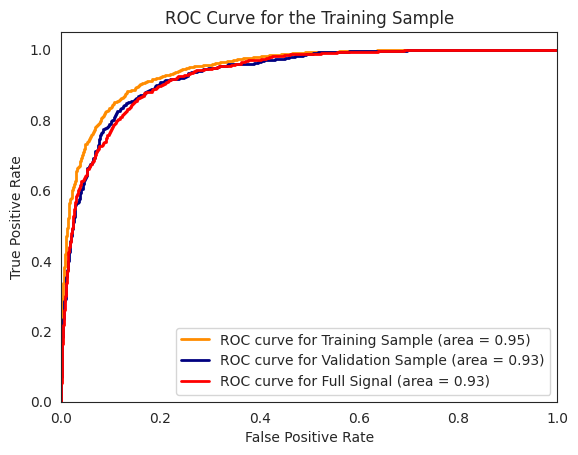

In [434]:
from sklearn.metrics import roc_curve
plt.figure()
#roc_curve(real_value, NN_score)
lw = 2
fprdev, tprdev, thresholdsdev = roc_curve(y_class_train,pred_train)
plt.plot(fprdev,tprdev,color='darkorange',lw=lw, label='ROC curve for Training Sample (area = %0.2f)' % devAUC)
fprval, tprval, thresholdsval = roc_curve(y_class_val,pred_val)
plt.plot(fprval, tprval, color='navy', lw=lw, label='ROC curve for Validation Sample (area = %0.2f)' % valAUC)
fprfull, tprfull, thresholdfull = roc_curve(y_class_test,pred_test)
plt.plot(fprfull, tprfull, color='red', lw=lw, label='ROC curve for Full Signal (area = %0.2f)' % testAUC)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for the Training Sample")
plt.legend(loc="lower right")
plt.show()

## Aplying the NN to the data set in order to obtain the probabilities of being signal

### This is for binary selection

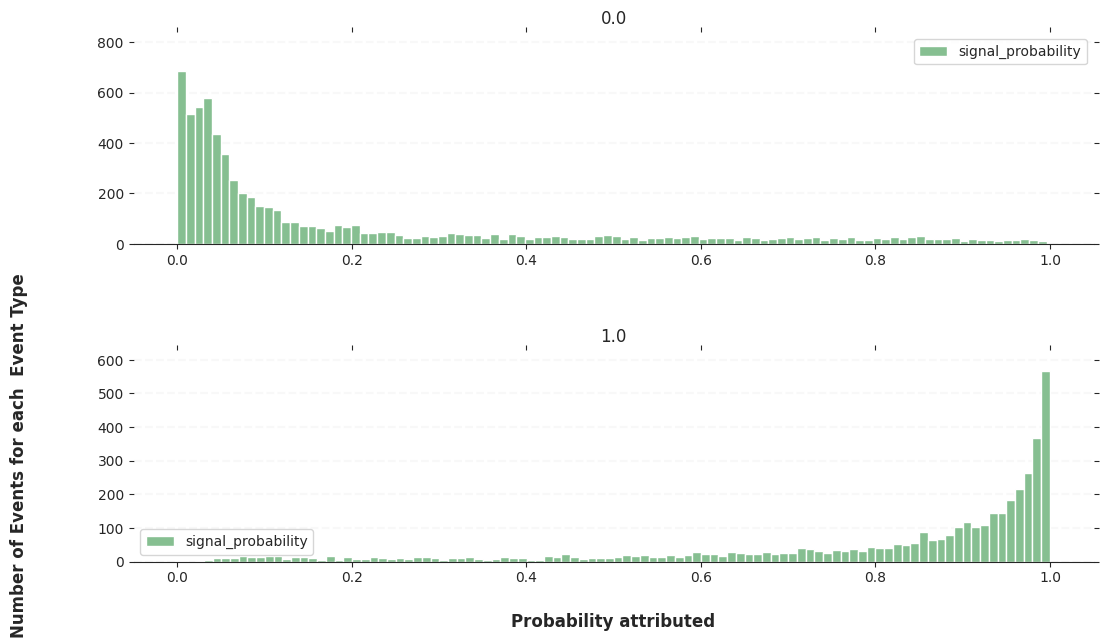

In [435]:
#Appending the score provided by the NN to the full dataset
FullSignal['signal_probability'] = pandas.Series(pred_full_Data[:,0])

#Printing out histograms with the score predictions for each event type
feature = ' Event Type'

ax = FullSignal.hist(column='signal_probability', by="target", bins=100, grid=False, figsize=(12,24), layout=(6,1), sharex=True, color='#86bf91', zorder=2, rwidth=1.0, log=False, legend=True, sharey=False)


for i,x in enumerate(ax):

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Set x-axis label
    x.set_xlabel("Probability attributed", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    if i == 1:
        x.set_ylabel("Number of Events for each "+feature, labelpad=50, weight='bold', size=12)



    x.tick_params(axis='x', rotation=0)

Cut    | S (Weighted)    | sqrt(B)    | S/sqrt(B) 
-------------------------------------------------------
0.00   | 24.9975         | 6.3401     | 3.94      
0.05   | 24.8951         | 4.8724     | 5.11      
0.10   | 24.5245         | 4.1339     | 5.93      
0.15   | 24.1222         | 3.7454     | 6.44      
0.20   | 23.8294         | 3.4792     | 6.85      
0.25   | 23.5839         | 3.2576     | 7.24      
0.30   | 23.2409         | 3.1282     | 7.43      
0.35   | 22.9820         | 2.9456     | 7.80      
0.40   | 22.7092         | 2.7894     | 8.14      
0.45   | 22.3545         | 2.6533     | 8.43      
0.50   | 22.0229         | 2.5083     | 8.78      
0.55   | 21.5118         | 2.3728     | 9.07      
0.60   | 20.9754         | 2.1983     | 9.54      
0.65   | 20.2891         | 2.0572     | 9.86      
0.70   | 19.5647         | 1.8919     | 10.34     
0.75   | 18.6241         | 1.6996     | 10.96     
0.80   | 17.5470         | 1.5144     | 11.59     
0.85   | 16.0954         |

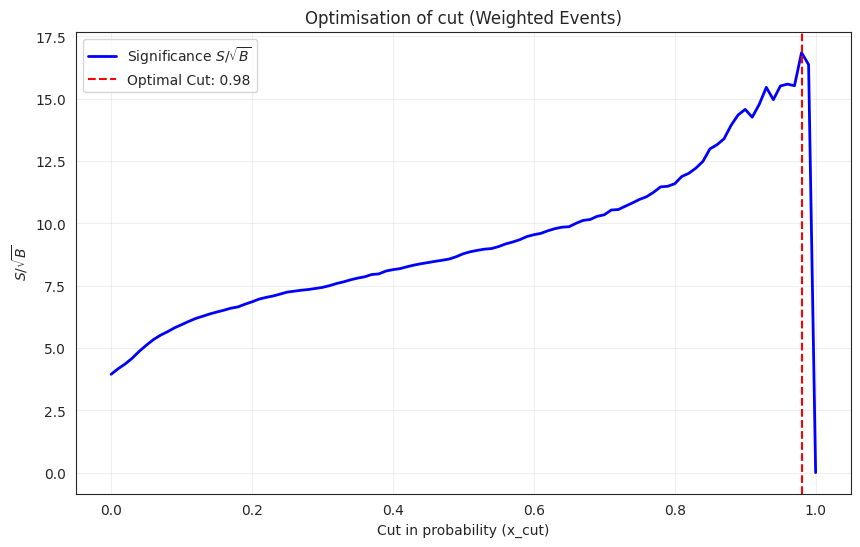


The best ratio S/sqrt(B) is 16.85 obtained with a cut at 0.98

EXPECTED YIELD RETENTION (WEIGHTED)
Total original yield   : 65.19 events
Total retained yield   : 5.97 events (9.15% of total)
-------------------------------------------------------
Original Signal (S)    : 25.00 events
Retained Signal (S)    : 5.85 events (23.39% signal efficiency)
-------------------------------------------------------
Original Background (B): 40.20 events
Retained Background (B): 0.12 events (0.30% background kept)


In [436]:
import numpy as np
import matplotlib.pyplot as plt
import pandas

if 'weight' not in FullSignal.columns:
    weights_column = pandas.concat([signal_df['weight'], background_df['weight']], ignore_index=True)
    FullSignal['weight'] = weights_column

cuts = np.arange(0.0, 1.01, 0.01)
significances = []

print(f"{'Cut':<6} | {'S (Weighted)':<15} | {'sqrt(B)':<10} | {'S/sqrt(B)':<10}")
print('-' * 55)

for x_cut in cuts:
    mask_S = (FullSignal['target'] == 1) & (FullSignal['signal_probability'] >= x_cut)
    mask_B = (FullSignal['target'] == 0) & (FullSignal['signal_probability'] >= x_cut)

    S = FullSignal[mask_S]['weight'].sum()
    B = FullSignal[mask_B]['weight'].sum()

    sqrtB = np.sqrt(B) if B > 0 else 0
    ratio = S / sqrtB if sqrtB > 0 else 0

    significances.append(ratio)

    if int(x_cut * 100) % 5 == 0:
        print(f"{x_cut:<6.2f} | {S:<15.4f} | {sqrtB:<10.4f} | {ratio:<10.2f}")

max_idx = np.argmax(significances)
best_cut = cuts[max_idx]
max_significance = significances[max_idx]

total_S_orig = FullSignal[FullSignal['target'] == 1]['weight'].sum()
total_B_orig = FullSignal[FullSignal['target'] == 0]['weight'].sum()
total_orig = total_S_orig + total_B_orig

surviving_S = FullSignal[(FullSignal['target'] == 1) & (FullSignal['signal_probability'] >= best_cut)]['weight'].sum()
surviving_B = FullSignal[(FullSignal['target'] == 0) & (FullSignal['signal_probability'] >= best_cut)]['weight'].sum()
total_surviving = surviving_S + surviving_B

pct_S = (surviving_S / total_S_orig) * 100 if total_S_orig > 0 else 0
pct_B = (surviving_B / total_B_orig) * 100 if total_B_orig > 0 else 0
pct_total = (total_surviving / total_orig) * 100 if total_orig > 0 else 0

plt.figure(figsize=(10, 6))
plt.plot(cuts, significances, label=r'Significance $S/\sqrt{B}$', color='blue', lw=2)
plt.axvline(best_cut, color='red', linestyle='--', label=f'Optimal Cut: {best_cut:.2f}')
plt.title('Optimisation of cut (Weighted Events)')
plt.xlabel('Cut in probability (x_cut)')
plt.ylabel(r'$S/\sqrt{B}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nThe best ratio S/sqrt(B) is {max_significance:.2f} obtained with a cut at {best_cut:.2f}")

print("\n" + "="*55)
print("EXPECTED YIELD RETENTION (WEIGHTED)")
print("="*55)
print(f"Total original yield   : {total_orig:.2f} events")
print(f"Total retained yield   : {total_surviving:.2f} events ({pct_total:.2f}% of total)")
print("-" * 55)
print(f"Original Signal (S)    : {total_S_orig:.2f} events")
print(f"Retained Signal (S)    : {surviving_S:.2f} events ({pct_S:.2f}% signal efficiency)")
print("-" * 55)
print(f"Original Background (B): {total_B_orig:.2f} events")
print(f"Retained Background (B): {surviving_B:.2f} events ({pct_B:.2f}% background kept)")
print("="*55)


### Surviving events analysis (Yields)
 Calculate absolute number of signal and background after the optimal cut

In [437]:
import pandas as pd

working_point = best_cut

total_S_orig = FullSignal[FullSignal['target'] == 1]['weight'].sum()
total_B_orig = FullSignal[FullSignal['target'] == 0]['weight'].sum()
total_orig = total_S_orig + total_B_orig

sig_final = FullSignal[(FullSignal['target'] == 1) & (FullSignal['signal_probability'] >= working_point)]['weight'].sum()
bkg_final = FullSignal[(FullSignal['target'] == 0) & (FullSignal['signal_probability'] >= working_point)]['weight'].sum()

yields_df = pd.DataFrame({
    'Categoría': ['Señal (S)', 'Fondo (B)', 'Total (S+B)'],
    'Yield Original': [total_S_orig, total_B_orig, total_orig],
    f'Yield tras Corte {working_point:.2f}': [sig_final, bkg_final, sig_final + bkg_final],
    'Eficiencia/Retención (%)': [f'{(sig_final/total_S_orig)*100:.2f}%', f'{(bkg_final/total_B_orig)*100:.2f}%', f'{((sig_final+bkg_final)/total_orig)*100:.2f}%']
})

display(yields_df)

print(f"\n--- Evaluación Estadística ---")
print(f"Relación S/B final: {(sig_final/np.sqrt(bkg_final)):.2f}" if bkg_final > 0 else "Relación S/B: Fondo cero en la muestra.")

,Categoría,Yield Original,Yield tras Corte 0.98,Eficiencia/Retención (%)
0,Señal (S),24.997528,5.847161,23.39%
1,Fondo (B),40.196316,0.120439,0.30%
2,Total (S+B),65.193844,5.967600,9.15%



--- Evaluación Estadística ---
Relación S/B final: 16.85


### Inspección de la Cola del Fondo (Background Tail)
Para validar la estadística gaussiana o poissoniana, debemos ver cómo se distribuyen esos pocos eventos de fondo que sobrevivieron al corte de 0.97.

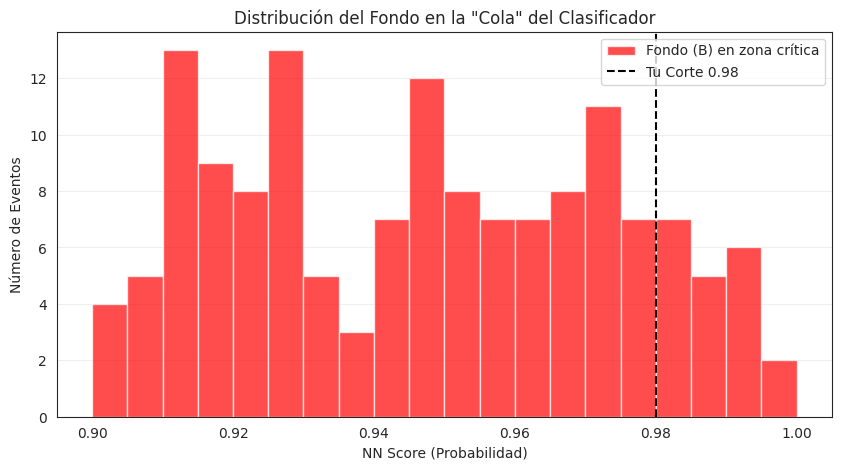

Eventos de fondo con score > 0.98: 38


In [438]:
import matplotlib.pyplot as plt

# Filtramos solo el fondo que sobrevive al corte
bkg_tail = FullSignal[(FullSignal['target'] == 0) & (FullSignal['signal_probability'] >= 0.90)]

plt.figure(figsize=(10, 5))
plt.hist(bkg_tail['signal_probability'], bins=20, range=(0.90, 1.0), color='red', alpha=0.7, label='Fondo (B) en zona crítica')
plt.axvline(best_cut, color='black', linestyle='--', label=f'Tu Corte {working_point:.2f}')

plt.title('Distribución del Fondo en la "Cola" del Clasificador')
plt.xlabel('NN Score (Probabilidad)')
plt.ylabel('Número de Eventos')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Eventos de fondo con score > {working_point:.2f}: {len(bkg_tail[bkg_tail['signal_probability'] >= 0.97])}")

### Cálculo de Yields con Pesos (Weighted Yields)
Para que los resultados sean físicamente realistas, sumamos la columna `weight` en lugar de contar eventos individuales. Esto es crucial para determinar si la estadística es Poisson o Gaussiana basada en el número de eventos esperados reales.

In [439]:
import numpy as np

# Recuperamos los pesos originales (ya que los borramos de FullSignal antes)
# Creamos un dataframe temporal con el score y el peso
weights_full = pandas.concat([signal_df['weight'], background_df['weight']], ignore_index=True)
FullSignal['weight'] = weights_full

working_point = best_cut

# Selección tras el corte
mask_sig = (FullSignal['target'] == 1) & (FullSignal['signal_probability'] >= working_point)
mask_bkg = (FullSignal['target'] == 0) & (FullSignal['signal_probability'] >= working_point)

# Eventos Pesados (Esperados)
S_weighted = FullSignal.loc[mask_sig, 'weight'].sum()
B_weighted = FullSignal.loc[mask_bkg, 'weight'].sum()

print(f"--- Yields Pesados (Corte {working_point}) ---")
print(f"Señal Esperada (S): {S_weighted:.4f}")
print(f"Fondo Esperado (B): {B_weighted:.4f}")

# Nuevo ratio con pesos
sig_weighted = S_weighted / np.sqrt(B_weighted) if B_weighted > 0 else 0
print(f"Significancia pesada S/sqrt(B): {sig_weighted:.4f}")

if S_weighted < 10:
    print('\nNOTA: El número de eventos esperados es muy bajo. El ratio de 207 era artificial por ser datos sin pesar.')

--- Yields Pesados (Corte 0.98) ---
Señal Esperada (S): 5.8472
Fondo Esperado (B): 0.1204
Significancia pesada S/sqrt(B): 16.8485

NOTA: El número de eventos esperados es muy bajo. El ratio de 207 era artificial por ser datos sin pesar.


### (Bias Check)
Compare how the threshold (best_cut) affects to the energy (Etrue) of the signal. For this we will use the original dataframe 'signal_df' (that contains the physical variables) and we will add the predicted probabilities.

Estadísticas de Etrue para Señal Total vs Seleccionada (Corte > 0.98):
Total - Media: 576.56, Std: 421.06
Cut   - Media: 837.30, Std: 443.87


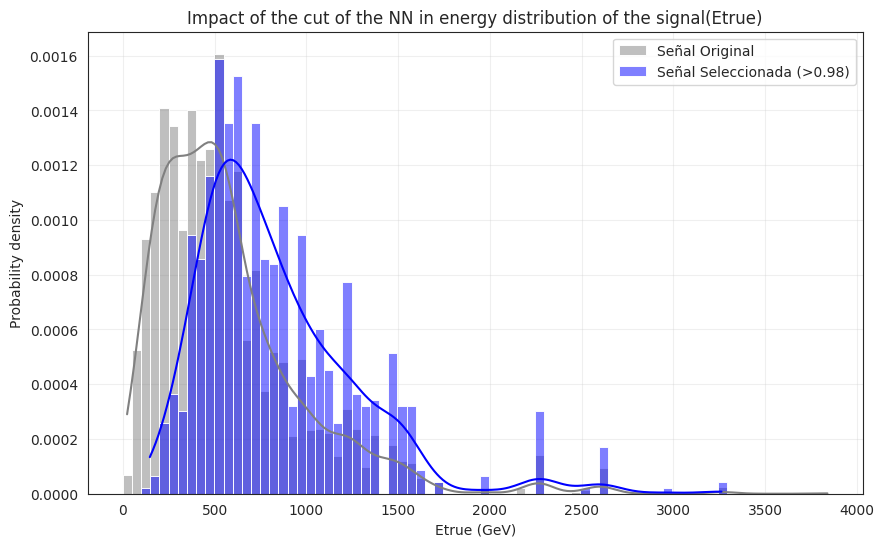

In [440]:
import seaborn as sns

# 1. Recover the energy for signal events
# Nota: Asumimos que el orden en signal_df se mantuvo igual al predecir
signal_with_score = signal_df.copy()
signal_with_score['nn_score'] = pred_full_Data[:len(signal_df), 0]

# 2. Create the subset that surpass the optimal cut

signal_selected = signal_with_score[signal_with_score['nn_score'] >= best_cut]

# 3. Comparison of basic statistics
print(f"Estadísticas de Etrue para Señal Total vs Seleccionada (Corte > {best_cut}):")
print(f"Total - Media: {signal_with_score['Etrue'].mean():.2f}, Std: {signal_with_score['Etrue'].std():.2f}")
print(f"Cut   - Media: {signal_selected['Etrue'].mean():.2f}, Std: {signal_selected['Etrue'].std():.2f}")

# 4. Visualización de las distribuciones
plt.figure(figsize=(10, 6))

 #Set the range for the energy to observe the comparison clearly
minimum_E = 0       # Forzamos a que ambos empiecen en 0
maximum_E = signal_with_score['Etrue'].max()
bin_width=50

sns.histplot(signal_with_score['Etrue'], label='Señal Original', color='gray',binwidth=bin_width, binrange=(minimum_E, maximum_E), kde=True, stat="density", alpha=0.5)
sns.histplot(signal_selected['Etrue'], label=f'Señal Seleccionada (>{best_cut})', color='blue', binwidth=bin_width, binrange=(minimum_E, maximum_E),  kde=True, stat="density", alpha=0.5)

plt.title('Impact of the cut of the NN in energy distribution of the signal(Etrue)')
plt.xlabel('Etrue (GeV)')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Do the same with the background in order to see how in affects the threshold to the background

Estadísticas de Etrue para el fondo Total vs Seleccionado (Corte > 0.98):
Total - Media: 360.26, Std: 345.92
Cut   - Media: 388.66, Std: 379.88


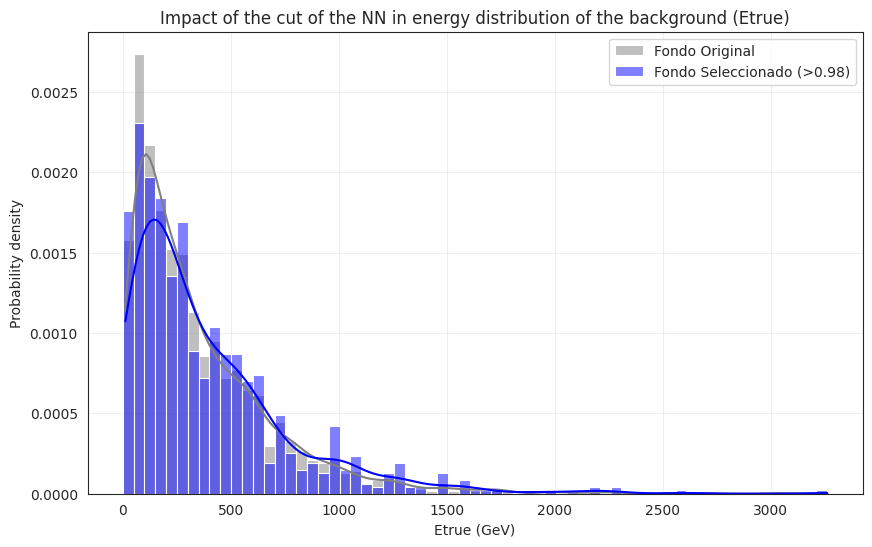

In [441]:
import seaborn as sns

# 1. Recover the energy for background events
# Nota: Asumimos que el orden en background_df se mantuvo igual al predecir
bkg_with_score = background_df.copy()
bkg_with_score['nn_score'] = pred_full_Data[:len(background_df), 0]

# 2. Create the subset that surpass the optimal cut

bkg_selected = bkg_with_score[bkg_with_score['nn_score'] >= best_cut]

# 3. Comparison of basic statistics
print(f"Estadísticas de Etrue para el fondo Total vs Seleccionado (Corte > {best_cut}):")
print(f"Total - Media: {bkg_with_score['Etrue'].mean():.2f}, Std: {bkg_with_score['Etrue'].std():.2f}")
print(f"Cut   - Media: {bkg_selected['Etrue'].mean():.2f}, Std: {bkg_selected['Etrue'].std():.2f}")

# 4. Visualización de las distribuciones
plt.figure(figsize=(10, 6))

 #Set the range for the energy to observe the comparison clearly
minimum_E = 0       # Forzamos a que ambos empiecen en 0
maximum_E = bkg_with_score['Etrue'].max()
#print(maximum_E)
bin_width=50

sns.histplot(bkg_with_score['Etrue'], label='Fondo Original', color='gray',binwidth=bin_width, binrange=(minimum_E, maximum_E), kde=True, stat="density", alpha=0.5)
sns.histplot(bkg_selected['Etrue'], label=f'Fondo Seleccionado (>{best_cut})', color='blue', binwidth=bin_width, binrange=(minimum_E, maximum_E),  kde=True, stat="density", alpha=0.5)

plt.title('Impact of the cut of the NN in energy distribution of the background (Etrue)')
plt.xlabel('Etrue (GeV)')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Multivariable bias checkEstudio de Sesgo Multivariable

Vamos a comparar la media y la forma de la distribución para todas las demás variables de entrada, comparando la muestra de señal completa vs. la señal que sobrevive al corte óptimo.

Mean Comparison (Original Signal vs Selected Signal):


,Variable,Original Mean,Cut Mean,Change %
0,f_n_hits_scifi_1,0.567402,0.255889,54.901698
1,f_n_hits_scifi_2,22.096814,4.502141,79.625382
2,f_n_hits_scifi_3,176.626716,156.391863,11.456281
3,f_n_hits_scifi_4,398.204657,455.213062,14.316358
4,f_n_hits_scifi_5,416.439216,647.170236,55.405690
5,f_n_hits_US_1,7.738725,7.343683,5.104748
6,f_n_hits_US_2,6.885539,5.964668,13.373987
7,f_n_hits_US_3,5.488971,4.412206,19.616885
8,f_n_hits_US_4,3.858578,2.899358,24.859436
9,f_n_hits_US_5,2.339216,1.572805,32.763569


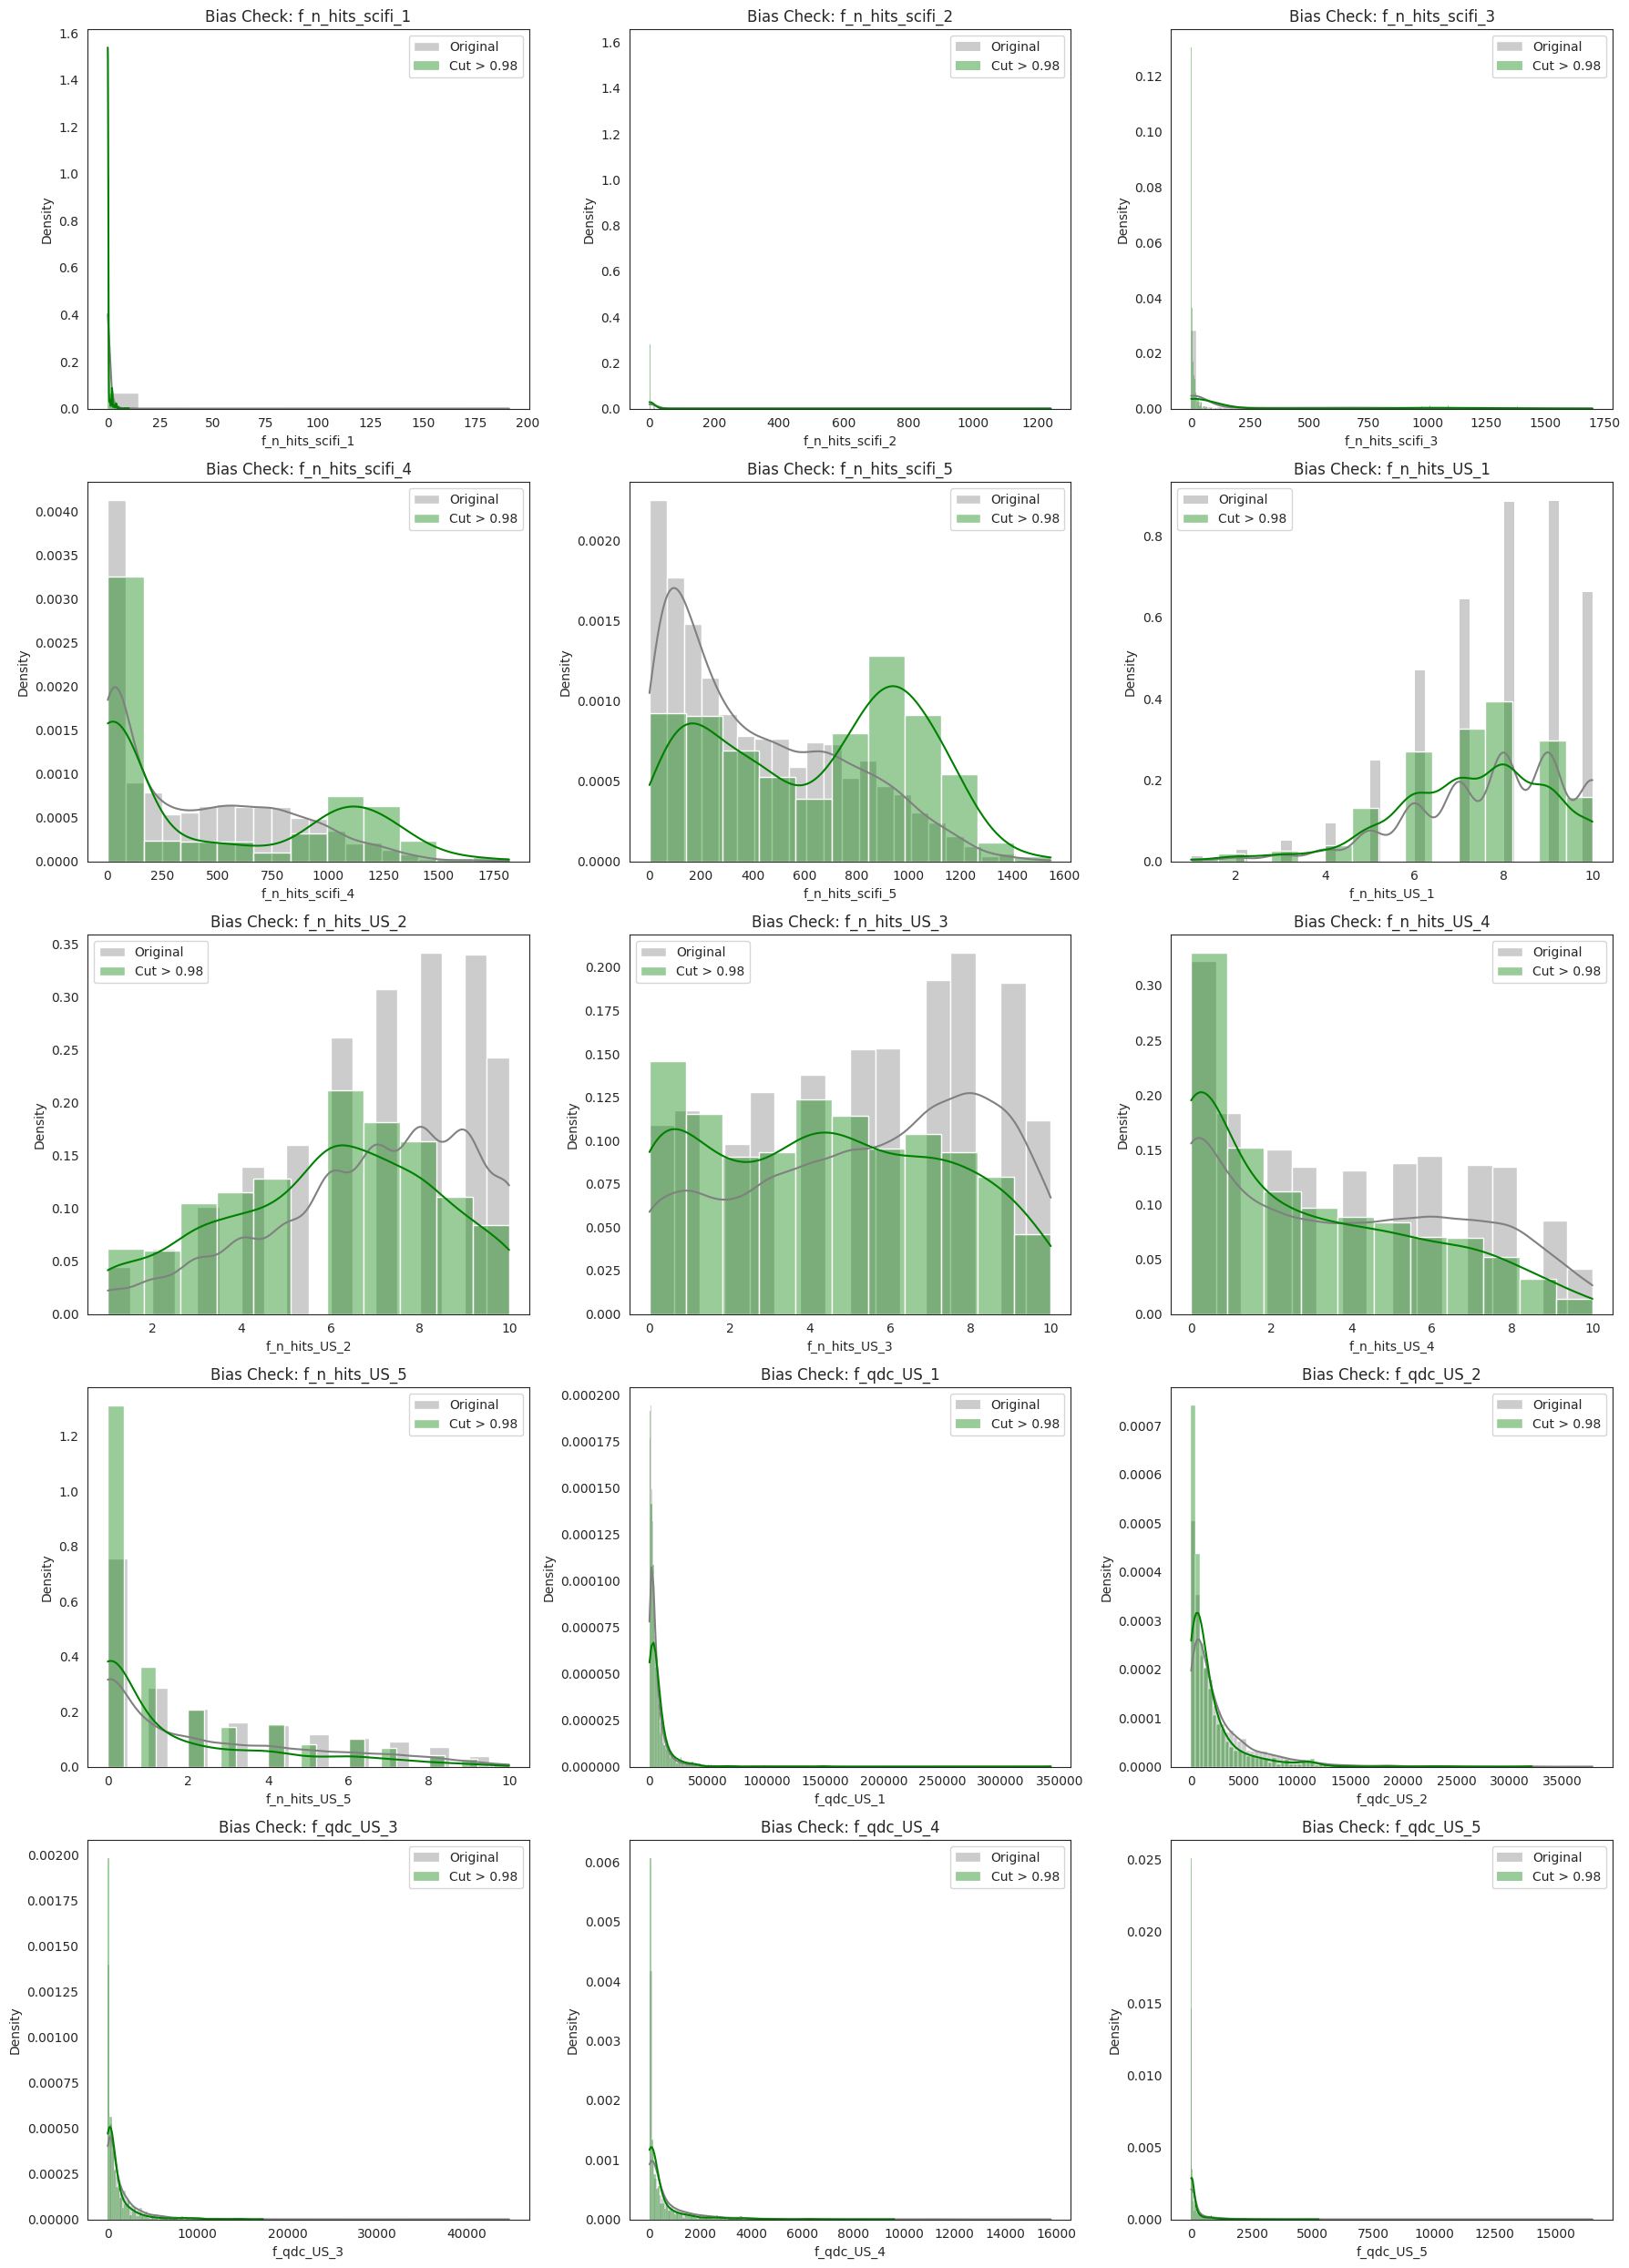

In [442]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation
# We use the optimal cut identified
signal_with_score = signal_df.copy()
signal_with_score['nn_score'] = pred_full_Data[:len(signal_df), 0]

# Filter the signal events that pass the selection cut
signal_selected = signal_with_score[signal_with_score['nn_score'] >= best_cut]

# 2. Define Variables to Check
# Lista de variables a excluir del entrenamiento
# Puedes añadir aquí cualquier variable que consideres que no aporta información
#exclude_vars1 = ['target', 'signal_probability', 'weight', 'f_n_hits_US_1']

# Creamos variables a comentar excluyendo las variables de la lista
#vars_to_check1 = [ var for var in FullSignal.columns if var not in exclude_vars ]


# Checking Etrue and a subset of hit/qdc features
vars_to_check1 =  [v for v in trainFeatures if 'hits' in v or 'qdc' in v]


# 3. Create Statistical Comparison Table
stats_comp = []
for var in vars_to_check1:
    mean_orig = signal_with_score[var].mean()
    mean_cut = signal_selected[var].mean()
    # Calculate percentage change to identify potential bias
    diff_pct = (abs(mean_orig - mean_cut) / mean_orig) * 100
    stats_comp.append({
        'Variable': var,
        'Original Mean': mean_orig,
        'Cut Mean': mean_cut,
        'Change %': diff_pct
    })

df_stats = pd.DataFrame(stats_comp)
print("Mean Comparison (Original Signal vs Selected Signal):")
display(df_stats)

# 4. Automated Visualization (Grid)
n_vars = len(vars_to_check1)
cols = 3
rows = (n_vars + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(vars_to_check1):
    # Normalized histograms (density) to compare shapes regardless of sample size
    sns.histplot(signal_with_score[var], color='gray', label='Original', kde=True, stat='density', ax=axes[i], alpha=0.4)
    sns.histplot(signal_selected[var], color='green', label=f'Cut > {best_cut}', kde=True, stat='density', ax=axes[i], alpha=0.4)
    axes[i].set_title(f'Bias Check: {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Density')
    axes[i].legend()

# Remove empty subplots if the number of variables isn't a multiple of columns
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretación:**

*   **Cambio % pequeño (< 5-10%):** El corte es robusto y no introduce sesgos importantes.
*   **Cambio % grande:** La red neuronal está "aprendiendo" que esa variable es fundamental para distinguir la señal. Debes evaluar si ese sesgo es aceptable para tu análisis físico posterior (por ejemplo, si vas a medir una sección eficaz dependiente de la energía).

Si las curvas normalizadas (densidad) se superponen bien, significa que tu selección es **independiente de la energía**, lo cual es muy deseable en física de partículas para evitar sesgos en la medición del flujo o la sección eficaz.

In [443]:
import os
import pandas as pd
from datetime import datetime

# 1. Definir la ruta del historial
history_file = project_path + "historial_compilaciones.csv"

# 2. Recopilar la información base de la ejecución actual
registro_actual = {
    'fecha_hora': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'num_features_entrenamiento': len(trainFeatures),
    'val_auc': valAUC,
    'test_auc': testAUC,
    'max_significance': max_significance
}

# 3. Añadir cada variable excluida como una columna independiente
for i, var in enumerate(exclude_vars):
    registro_actual[f'excluded_var_{i+1}'] = var

df_nuevo = pd.DataFrame([registro_actual])

# 4. Guardar o anexar al CSV
if os.path.exists(history_file):
    df_historial = pd.read_csv(history_file)
    # Concatenamos y nos aseguramos de que pandas maneje las nuevas columnas (rellenando con NaN las anteriores)
    df_historial = pd.concat([df_historial, df_nuevo], ignore_index=True)
else:
    df_historial = df_nuevo

# Guardar el CSV con todas las columnas
df_historial.to_csv(history_file, index=False)

print(f"✅ Historial actualizado con columnas individuales para variables en: {history_file}")
# Mostramos las últimas filas del historial para verificar la estructura de columnas
display(df_historial.tail())


✅ Historial actualizado con columnas individuales para variables en: /content/drive/MyDrive/LIP_internships26_SNDNue/historial_compilaciones.csv


,fecha_hora,num_features_entrenamiento,val_auc,test_auc,max_significance,excluded_var_1,excluded_var_2,excluded_var_3,excluded_var_4,excluded_var_5,excluded_var_6,excluded_var_7,excluded_var_8,excluded_var_9,excluded_var_10,excluded_var_11
10,2026-07-23 11:03:12,23,0.934363,0.932243,17.475488,target,signal_probability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,2026-07-23 11:05:56,22,0.910939,0.909668,18.594599,target,signal_probability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2026-07-23 11:25:31,22,0.911358,0.910343,20.039175,target,signal_probability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,2026-07-23 11:29:12,22,0.912003,0.909823,19.622709,target,signal_probability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2026-07-23 11:32:14,23,0.930556,0.929436,16.848485,target,signal_probability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
